### Crypto-ML-Pairs-Trading (CLEAN) (Perp. Futures) (BinanceEX/HyperLiquid)

<b><u> Statistical-Arbitraging </u></b>

1. Start beta-neutral to isolate and test if strategy generates true alpha, independent of market moves.

2. Evaluate signal quality, if consistent alpha shows up, it's a valid edge and not just hidden beta.

3. Add back beta exposure (e.g., via index ETFs) to scale returns, creating a robust (beta + alpha) portfolio.

<p align="center">
  <span style="font-size:24px; font-weight:bold;"> Trade System Architecture (R&D) </span><br>
  <img src="../theory/ML-pairs-open-arch.png" width="40%">
</p>


#### Research

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
import os
from pprint import pprint
import seaborn as sns

from IPython.display import display
import time
from warnings import filterwarnings
import importlib
import pickle
import json
import os
from dotenv import load_dotenv
load_dotenv()


filterwarnings('ignore') 

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [3]:
import utils
import utils.methods
import utils.retrieve
import utils.cluster
import utils.benchmark
import utils.portfolio
import utils.position

importlib.reload(utils.methods)
importlib.reload(utils.retrieve)
importlib.reload(utils.cluster)
importlib.reload(utils.benchmark)
importlib.reload(utils.portfolio)
importlib.reload(utils.position)

<module 'utils.position' from 'c:\\Users\\Alik\\Desktop\\M_year\\MPhil\\Options\\Quant&Finance\\QRT_Acad\\ML-Pairs-Open\\Research\\utils\\position.py'>

In [4]:
from utils.methods import *
from utils.retrieve import *
from utils.cluster import *
from utils.benchmark import *
from utils.portfolio import *
from utils.position import *

In [5]:
with open("config.json", "r") as f:
    config = json.load(f)

# Access variables
const_inner_col = config["cryp_tmp_fields"]
cryp_market = config["cryp_benchmark"]
start = config["start"]
end = config["end"]
day_limit = config["day_limit"]
variance_perc = config["variance_perc"]
cluster_distance_threshold = config["cluster_distance_threshold"]
cluster_percentile = config["cluster_percentile"]

print(const_inner_col, start, end)

['close', 'open', 'high', 'low', 'volume'] 2021-01-01 2024-12-31


Data-Load (BinanceEX API)

In [6]:
stable_ticker = 'USDC/USDT'
history_limit = 1000

In [7]:
df_cryp_uni, cryp_uni_list = get_ccxt_crypto_data(timeframe='1d', limit=history_limit, is_plot=False, load_universe=True)

stablecoin_df = df_cryp_uni.loc[stable_ticker]

df_cryp_uni.drop([stable_ticker], axis=0)
cryp_uni_list = [c for c in cryp_uni_list if c not in [stable_ticker]]

USDT-markets-retrieved:  597 ['BTC/USDT', 'ETH/USDT']
Batch fetch_tickers failed: binance GET https://api.binance.com/api/v3/ticker/24hr?symbols=%5B%22BTCUSDT%22%2C%22ETHUSDT%22%2C%22BNBUSDT%22%2C%22BCCUSDT%22%2C%22NEOUSDT%22%2C%22LTCUSDT%22%2C%22QTUMUSDT%22%2C%22ADAUSDT%22%2C%22XRPUSDT%22%2C%22EOSUSDT%22%2C%22TUSDUSDT%22%2C%22IOTAUSDT%22%2C%22XLMUSDT%22%2C%22ONTUSDT%22%2C%22TRXUSDT%22%2C%22ETCUSDT%22%2C%22ICXUSDT%22%2C%22VENUSDT%22%2C%22NULSUSDT%22%2C%22VETUSDT%22%2C%22PAXUSDT%22%2C%22BCHABCUSDT%22%2C%22BCHSVUSDT%22%2C%22USDCUSDT%22%2C%22LINKUSDT%22%2C%22WAVESUSDT%22%2C%22BTTUSDT%22%2C%22USDSUSDT%22%2C%22ONGUSDT%22%2C%22HOTUSDT%22%2C%22ZILUSDT%22%2C%22ZRXUSDT%22%2C%22FETUSDT%22%2C%22BATUSDT%22%2C%22XMRUSDT%22%2C%22ZECUSDT%22%2C%22IOSTUSDT%22%2C%22CELRUSDT%22%2C%22DASHUSDT%22%2C%22NANOUSDT%22%2C%22OMGUSDT%22%2C%22THETAUSDT%22%2C%22ENJUSDT%22%2C%22MITHUSDT%22%2C%22MATICUSDT%22%2C%22ATOMUSDT%22%2C%22TFUELUSDT%22%2C%22ONEUSDT%22%2C%22FTMUSDT%22%2C%22ALGOUSDT%22%2C%22USDSBUSDT%22%2C%22GTOU

open     high      low    close        volume
symbol   datetime                                                    
ETH/USDT 2022-11-07  1568.25  1608.04  1545.03  1568.10  6.424094e+05
         2022-11-08  1568.09  1579.98  1233.00  1334.77  2.339917e+06
         2022-11-09  1334.78  1337.16  1073.53  1102.73  2.494798e+06
         2022-11-10  1102.73  1350.00  1085.93  1299.28  1.975956e+06
         2022-11-11  1299.28  1310.00  1201.26  1289.28  1.308087e+06

In [8]:
print('Selected-coins (except market & stable): ', len(cryp_uni_list), cryp_uni_list[:5])
print()
display(df_cryp_uni.head(2))
print()
display(stablecoin_df.head(2))

Selected-coins (except market & stable):  95 ['ETH/USDT', 'BTC/USDT', 'XRP/USDT', 'SOL/USDT', 'DOGE/USDT']



open     high      low    close        volume
symbol   datetime                                                    
ETH/USDT 2022-11-07  1568.25  1608.04  1545.03  1568.10  6.424094e+05
         2022-11-08  1568.09  1579.98  1233.00  1334.77  2.339917e+06

,open,high,low,close,volume
datetime,,,,,
2022-05-26,1.0010,1.0014,1.001,1.0012,438174187.0
2022-05-27,1.0012,1.0013,1.001,1.0013,333404208.0


#### ~2.5 Years API Call-Limit
Different tokens got listed at different times in Binance, and some got de-listed at different times 

Rnd-Coin-Chosen:  ALICE/USDT


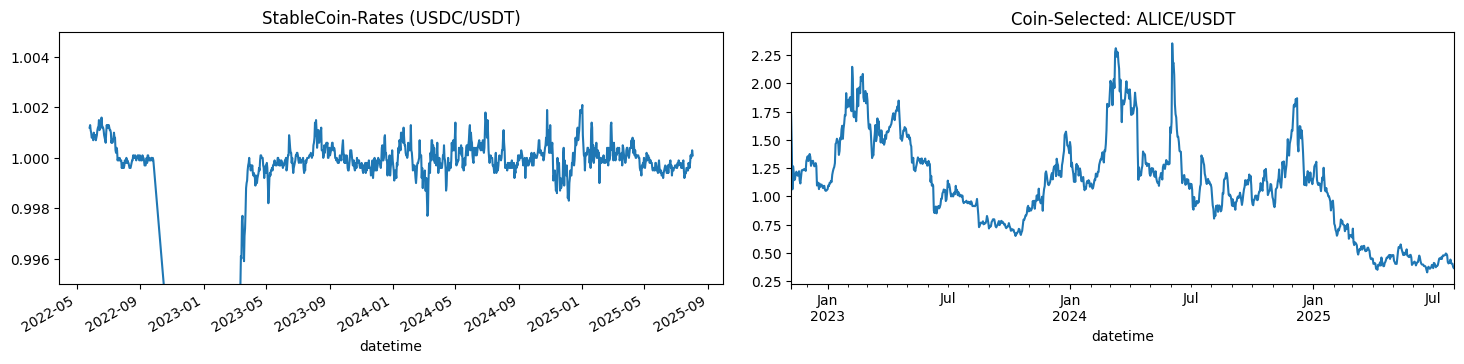

In [9]:
rn_coin = random.randint(0, len(cryp_uni_list))
rn_coin = cryp_uni_list[rn_coin]
print('Rnd-Coin-Chosen: ', rn_coin)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

stablecoin_df.close.plot(ax=axs[0])
axs[0].set_title('StableCoin-Rates (USDC/USDT)')
axs[0].set_ylim(0.995, 1.005)

df_cryp_uni.loc[rn_coin].close.plot(ax=axs[1])
axs[1].set_title(f'Coin-Selected: {rn_coin}')

plt.tight_layout(pad=2)
plt.show()

In [10]:
sub_sample = 20

In [11]:
stocks = np.random.choice(np.array(cryp_uni_list), size=sub_sample).tolist()
print('sampled-selected: ', stocks)

df_uni = df_cryp_uni.copy()
df_uni = df_uni.loc[stocks]

df_cleaned = []
for nm in stocks:
    df_filtered = df_uni.loc[nm].copy()
    df_filtered = df_filtered[~df_filtered.index.duplicated(keep='first')]
    df_filtered['symbol'] = nm  
    df_cleaned.append(df_filtered)

# Combine and set multi-index again
df_uni = pd.concat(df_cleaned).set_index('symbol', append=True).swaplevel()
df_uni = df_uni.sort_index()

display(df_uni.head(3))

sampled-selected:  ['REEF/USDT', 'KNC/USDT', 'BCH/USDT', 'CELO/USDT', 'LTC/USDT', 'BCH/USDT', 'CRV/USDT', 'ADA/USDT', 'SPELL/USDT', 'BLZ/USDT', 'BTC/USDT', 'SHIB/USDT', 'REEF/USDT', 'ANKR/USDT', 'CRV/USDT', 'DASH/USDT', 'SPELL/USDT', 'CTSI/USDT', 'OCEAN/USDT', 'RLC/USDT']


open    high     low   close       volume
symbol   datetime                                               
ADA/USDT 2022-11-07  0.4021  0.4161  0.3975  0.4041  138637231.9
         2022-11-08  0.4040  0.4156  0.3463  0.3722  379698137.7
         2022-11-09  0.3721  0.3766  0.3100  0.3175  397998672.0

Multi-Visualization (RAW)

LEN_REEF/USDT: 2000 | start=2021-12-01 00:00:00, end=2024-08-26 00:00:00
LEN_KNC/USDT: 1000 | start=2022-11-07 00:00:00, end=2025-08-02 00:00:00
LEN_BCH/USDT: 2000 | start=2022-11-07 00:00:00, end=2025-08-02 00:00:00
LEN_CELO/USDT: 1000 | start=2022-11-07 00:00:00, end=2025-08-02 00:00:00
LEN_LTC/USDT: 1000 | start=2022-11-07 00:00:00, end=2025-08-02 00:00:00
LEN_BCH/USDT: 2000 | start=2022-11-07 00:00:00, end=2025-08-02 00:00:00
LEN_CRV/USDT: 2000 | start=2022-11-07 00:00:00, end=2025-08-02 00:00:00
LEN_ADA/USDT: 1000 | start=2022-11-07 00:00:00, end=2025-08-02 00:00:00
LEN_SPELL/USDT: 2000 | start=2022-11-07 00:00:00, end=2025-08-02 00:00:00
LEN_BLZ/USDT: 1000 | start=2022-04-01 00:00:00, end=2024-12-25 00:00:00
LEN_BTC/USDT: 1000 | start=2022-11-07 00:00:00, end=2025-08-02 00:00:00
LEN_SHIB/USDT: 1000 | start=2022-11-07 00:00:00, end=2025-08-02 00:00:00
LEN_REEF/USDT: 2000 | start=2021-12-01 00:00:00, end=2024-08-26 00:00:00
LEN_ANKR/USDT: 1000 | start=2022-11-07 00:00:00, end=2025-

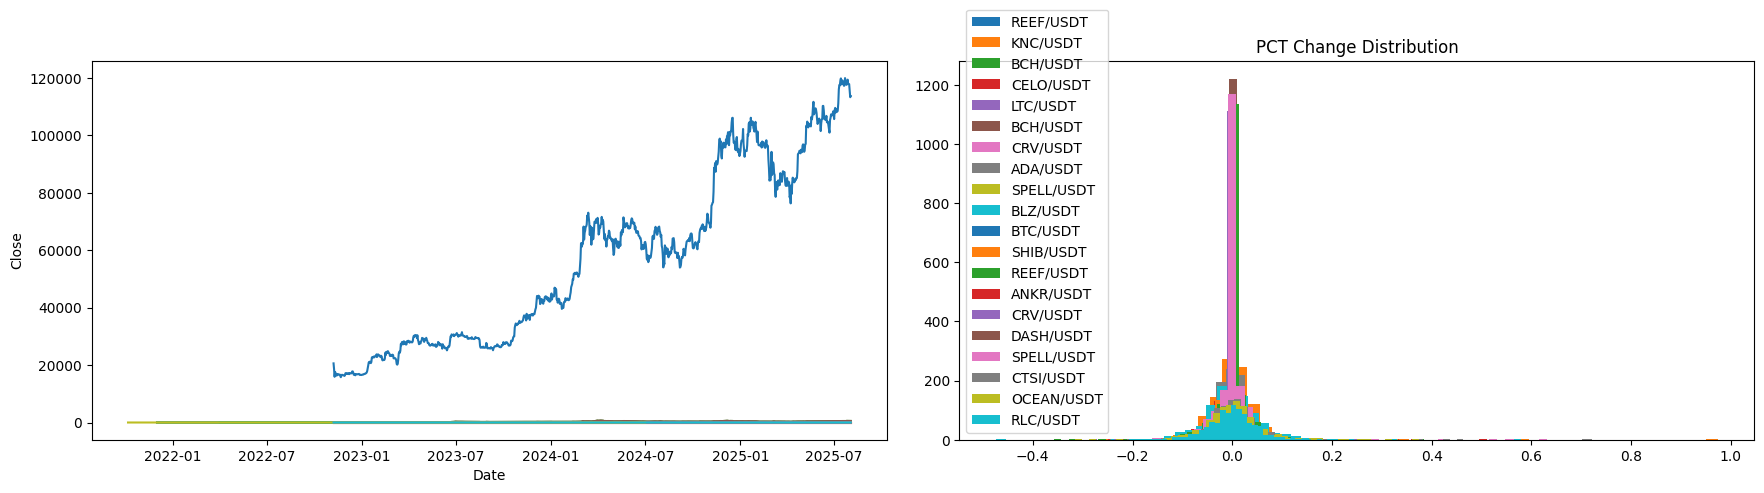

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(18, 5))

### We just do multi-indexing
for nm in stocks:
    print(f'LEN_{nm}: {len(df_uni.loc[nm].index)} | start={df_uni.loc[nm].index[0]}, end={df_uni.loc[nm].index[-1]}')
    axs[0].plot(df_uni.loc[nm].index, df_uni.loc[nm]['close'], label = nm)
    axs[0].set_xlabel('Date')
    axs[0].set_ylabel('Close')

plt.legend()

for nm in stocks:

    pct_change_clean = df_uni.loc[nm]['close'].pct_change().dropna()

    if pct_change_clean.empty:
        print(f"Skipping {nm} due to no valid percentage change data.")
        continue
    
    axs[1].hist(pct_change_clean, bins = 50, label = nm)
    axs[1].set_title(f'PCT Change Distribution')

plt.tight_layout(pad = 2)
plt.legend()
plt.show()

Data-Cleaning 

In [13]:
## returns factor-arrays (takes types and fundamental_df)
val_arr, stocks = data_clean(df_uni=df_uni, stocks=stocks, history_limit=history_limit, type='cryp', fund_df=None, is_plot=False)
    
print(len(val_arr), len(val_arr[0]))
val_arr = np.array(val_arr)
print(val_arr.shape)

print('New-Stocks: ', stocks)
print(len(stocks))

val_arr = val_arr.reshape(len(stocks), -1)
print(val_arr.shape)

Data-Cleaning ...
token REEF/USDT de-listed!
token BLZ/USDT de-listed!
token REEF/USDT de-listed!
token OCEAN/USDT de-listed!
time-taken for data-cleaning:  0.0007180929183959961  mins
16 3
(16, 3, 1000)
New-Stocks:  ['KNC/USDT', 'BCH/USDT', 'CELO/USDT', 'LTC/USDT', 'BCH/USDT', 'CRV/USDT', 'ADA/USDT', 'SPELL/USDT', 'BTC/USDT', 'SHIB/USDT', 'ANKR/USDT', 'CRV/USDT', 'DASH/USDT', 'SPELL/USDT', 'CTSI/USDT', 'RLC/USDT']
16
(16, 3000)


PortFolio-Construction

In [14]:
import utils
import utils.retrieve
import utils.benchmark

importlib.reload(utils.retrieve)
importlib.reload(utils.benchmark)

from utils.retrieve import *
from utils.benchmark import *

In [15]:
import utils

import utils.factor_model
import utils.market_proxy
import utils.alpha_ex
import utils.beta_ex
import utils.portfolio
import utils.risk_engine
import utils.backtest
import utils.forward_test
import utils.analytics

importlib.reload(utils.factor_model)
importlib.reload(utils.market_proxy)
importlib.reload(utils.alpha_ex)
importlib.reload(utils.beta_ex)
importlib.reload(utils.portfolio)
importlib.reload(utils.risk_engine)
importlib.reload(utils.backtest)
importlib.reload(utils.forward_test)
importlib.reload(utils.analytics)

<module 'utils.analytics' from 'c:\\Users\\Alik\\Desktop\\M_year\\MPhil\\Options\\Quant&Finance\\QRT_Acad\\ML-Pairs-Open\\Research\\utils\\analytics.py'>

In [16]:
from utils.factor_model import *
from utils.alpha_ex import *
from utils.beta_ex import *
from utils.portfolio import *
from utils.risk_engine import *
from utils.backtest import *
from utils.forward_test import *
from utils.analytics import *
from utils.market_proxy import * 

##### For the research env everything will be executed independently akin to their modularized nature

In [17]:
# 'test_data' to independently check indiviual components
timeline = df_uni.loc[stocks[0]].index
test_time_index = random.randint(0, len(timeline) - 1)
test_time = timeline[test_time_index]

print('test_time/test_time_index: ', test_time, '|', test_time_index, '|', type(test_time))
display(df_uni.head(3))

test_time/test_time_index:  2023-01-29 00:00:00 | 83 | <class 'pandas._libs.tslibs.timestamps.Timestamp'>


open    high     low   close       volume
symbol   datetime                                               
ADA/USDT 2022-11-07  0.4021  0.4161  0.3975  0.4041  138637231.9
         2022-11-08  0.4040  0.4156  0.3463  0.3722  379698137.7
         2022-11-09  0.3721  0.3766  0.3100  0.3175  397998672.0

Synthetic-Index-Retrieval

In [18]:
from utils.market_proxy import *

Beta-Basket:  ['BTC/USDT', 'ETH/USDT', 'SOL/USDT']


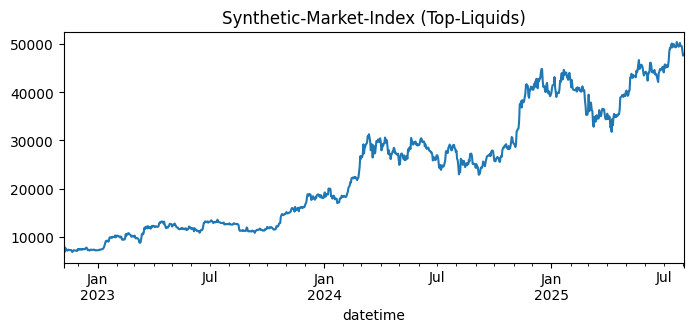

In [19]:
market = MarketProxy(df_cryp_uni, top_n=3)

## index-weightage is independent of token-metadata (so NOT Ideal)
market_df, beta_basket = market.get_syn_index(ret_beta_basket=True)

print('Beta-Basket: ', beta_basket)

fig = plt.figure(figsize=(8, 3))
market_df.plot()
plt.title('Synthetic-Market-Index (Top-Liquids)')
plt.show()

In [20]:
## Call factor_model and pass the retrieved clean/data
factor_model = FactorModelPairs(stocks, variance_perc, is_plot=False)
pairs = factor_model.run(val_arr, df_uni, start_time=test_time, start_time_index=test_time_index)

Decomposed-Dim:  1
Agglom - nunmber of clusters generated:  7
 ---- Clusters ---- 

{2: ['KNC/USDT', 'CELO/USDT', 'CRV/USDT', 'CRV/USDT'], 1: ['BCH/USDT', 'BCH/USDT'], 4: ['LTC/USDT'], 0: ['ADA/USDT', 'SPELL/USDT', 'SHIB/USDT', 'ANKR/USDT', 'SPELL/USDT', 'CTSI/USDT'], 3: ['BTC/USDT'], 5: ['DASH/USDT'], 6: ['RLC/USDT']}

 ------------- 
Testing cointegration in cluster 2 with 4 symbols.
P-Value:  0.10868521561716205
Error testing pair KNC/USDT-CRV/USDT: endog and exog matrices are different sizes
Error testing pair KNC/USDT-CRV/USDT: endog and exog matrices are different sizes
Error testing pair CELO/USDT-CRV/USDT: endog and exog matrices are different sizes
Error testing pair CELO/USDT-CRV/USDT: endog and exog matrices are different sizes
P-Value:  0.0
Cointegrated pair found: CRV/USDT_CRV/USDT with p-value 0.0 and Hurst -0.18
Testing cointegration in cluster 1 with 2 symbols.
P-Value:  0.0
Cointegrated pair found: BCH/USDT_BCH/USDT with p-value 0.0 and Hurst -1.54
Testing cointegratio

c:\Users\Alik\Desktop\M_year\MPhil\Options\Quant&Finance\QRT_Acad\ML-Pairs-Open\Research\utils\methods.py:42: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  coint_t, pvalue, _ = coint(prices_i, prices_j)
c:\Users\Alik\Desktop\M_year\MPhil\Options\Quant&Finance\QRT_Acad\ML-Pairs-Open\Research\utils\methods.py:42: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  coint_t, pvalue, _ = coint(prices_i, prices_j)
c:\Users\Alik\Desktop\M_year\MPhil\Options\Quant&Finance\QRT_Acad\ML-Pairs-Open\Research\utils\methods.py:42: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  coint_t, pvalue, _ = coint(prices_i, prices_j)


Predictive-Arbitrage (Alpha/Beta-Ex -> Risk-Engine)

In [ ]:
initial_positions = {} ## No-Position
lookback_window = 60
entry_z = 2.5 
exit_z = 0.5

alpha_alloction = 0.4 ## max-portfolio-weight-allocation for alpha
beta_allocation = 0.6 ## max-portfolio-weight-allocation for beta

In [22]:
## Call alpha_ex and pass the coint_pairs
alpha = PairsTradingAlpha(pairs, lookback_window=lookback_window, entry_z=entry_z, exit_z=exit_z)
target_position_alpha = alpha.generate_signal(timestamp=test_time, current_positions=initial_positions)

print('alpha-target-position: ', target_position_alpha)

alpha-target-position:  {'CRV/USDT_CRV/USDT': 0, 'BCH/USDT_BCH/USDT': 0, 'ADA/USDT_ANKR/USDT': 0, 'SPELL/USDT_SPELL/USDT': 0}


In [23]:
## Call beta_ex and get the beta_exposure
beta = SimpleMarketBeta(market_proxy=market_df, long_term_ma=200)
target_position_beta = beta.generate_signal(timestamp=test_time)

print('beta-target-position: ', target_position_beta)

beta-target-position:  0.0


In [ ]:
## Call portfolio and pass the alpha and beta exposure - calculate ideal-portfolio-weight allocation 
portfolio = PortfolioConstructor(alpha_allocation=alpha_alloction, beta_allocation=beta_allocation, beta_basket=beta_basket)
portfolio_weights = portfolio.construct_target_weights(alpha_signals=target_position_alpha, beta_signal=target_position_beta)
print('portfolio_weights: ', portfolio_weights)

portfolio_weights:  {}


In [25]:
random_portfolio_state = {
    # --- Portfolio-Level Financials ---
    "equity": 108500.00,
    "cash": 65000.00,  # Capital not currently used as margin
    "high_water_mark": 120000.00,  # All-time high equity

    # --- Portfolio-Level Risk Metrics ---
    # Calculated from the positions below
    "drawdown": 0.0958,  # (1 - 108500 / 120000). Set close to a 10% limit.
    "leverage": 0.8,     # Gross leverage from all asset exposures.

    # --- Core Positions Dictionary (keyed by PAIR) ---
    "positions": {
        'BTCUSDT-ETHUSDT': {
            'status': 'ACTIVE_LONG', # Human-readable status
            'signal': 1,             # The raw signal that initiated this position
            'pair_weight': 0.4,      # The capital allocated to this specific pair trade
            'asset_positions': {     # The actual resulting asset holdings
                'BTCUSDT': { 'size': 0.3, 'entry_price': 61000.00 },
                'ETHUSDT': { 'size': -5.1, 'entry_price': 3000.00 } # Hedge ratio = 17
            }
        },
        'SOLUSDT-AVAXUSDT': {
            'status': 'ACTIVE_SHORT',
            'signal': -1,
            'pair_weight': 0.4,
            'asset_positions': {
                'SOLUSDT': { 'size': -60.0, 'entry_price': 150.00 },
                'AVAXUSDT': { 'size': 180.0, 'entry_price': 30.00 } # Hedge ratio = 5
            }
        }
        # Note: A pair like 'LINKUSDT-UNIUSDT' might be flat (not in the dict)
    }
}

In [27]:
import utils.risk_engine
importlib.reload(utils.risk_engine)
from utils.risk_engine import *

In [26]:
## Call risk_engine and add execution/liquidity/volume/positional caps/constraints
risk_manager = RiskManager(max_leverage=1, max_concentration=1, max_portfolio_drawdown=10)
hedged_portfoilo_weights = risk_manager.manage_weights(target_weights=portfolio_weights, portfolio_state=random_portfolio_state)
print("hedged_portfoilo_weights: ", hedged_portfoilo_weights)

KeyError: 'value'

PORTFOLIO-Backtesting

In [30]:
# --- 2. Define Configuration ---
FEE_CONFIG = {'maker': 0.00018, 'taker': 0.00045}
INITIAL_CAPITAL = 100000.0
ALPHA_ALLOCATION = 0.6
BETA_ALLOCATION = 0.4
BETA_BASKET = beta_basket

In [31]:
start = df_uni.loc[stocks[0]].index[0]
end = df_uni.loc[stocks[0]].index[-1]

print(f'start: {start}, end: {end}')

start: 2022-11-05 00:00:00, end: 2025-07-31 00:00:00


In [56]:
import utils
import utils.fees_model

importlib.reload(utils.fees_model)
from utils.fees_model import *

In [33]:
from binance.client import Client

In [34]:
api_key = os.environ.get('BINANCE_API_KEY')
api_secret = os.environ.get('BINANCE_API_SECRET')

In [35]:
client = Client(api_key, api_secret)

##### Funding rates are published every 8 hours (3 times per day).
##### We aggregate these to compute the net daily funding by summing the values within each calendar day.

In [ ]:
fees_model = FeesModel()
funding_df = fees_model.get_funding_rate_history(client, stocks, start, end)

display(funding_df.head(3))

print()

new_index = [(s[:-4] + '/' + s[-4:], ts) for s, ts in funding_df.index]
funding_df.index = pd.MultiIndex.from_tuples(new_index, names=funding_df.index.names)

display(funding_df.head(3))

Fetching historical funding rates...
  - Fetching for 1INCHUSDT
  - Fetching for DASHUSDT
  - Fetching for DASHUSDT
  - Fetching for LPTUSDT
  - Fetching for BNBUSDT
  - Fetching for FETUSDT
  - Fetching for CELRUSDT
  - Fetching for ARPAUSDT
  - Fetching for SHIBUSDT
  - Fetching for YGGUSDT
  - Fetching for MASKUSDT
  - Fetching for THETAUSDT
  - Fetching for TRBUSDT
  - Fetching for IMXUSDT
  - Fetching for DASHUSDT
  - Fetching for BATUSDT
  - Fetching for DOGEUSDT
Funding data successfully aggregated to daily and multi-indexed.


fundingRate
symbol    date                   
1INCHUSDT 2022-11-05     0.000300
          2022-11-06     0.000012
          2022-11-07     0.000235

fundingRate
symbol     date                   
1INCH/USDT 2022-11-05     0.000300
           2022-11-06     0.000012
           2022-11-07     0.000235

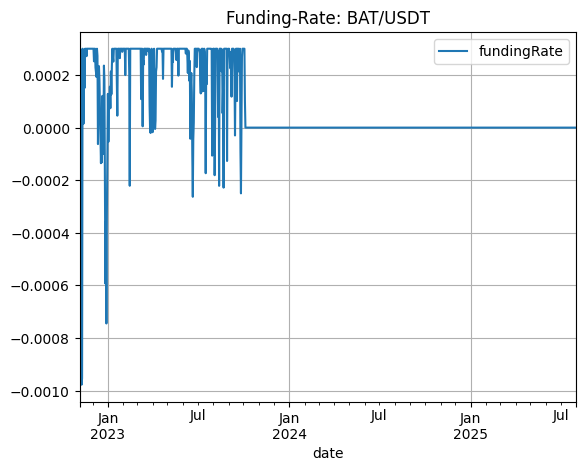

In [86]:
rn = random.randint(0, len(stocks) - 1)
test_token = stocks[rn]

fig = plt.Figure(figsize = (4, 3))

funding_df.loc[test_token].plot()
plt.title(f'Funding-Rate: {test_token}')

plt.grid()
plt.show()

We are witnessing here the artifact of deprecated API endpoint - Need to use <code>ccxt</code> library for USD-(M) (settled in USDT)

In [ ]:
alpha_generator = PairsTradingAlpha(
    pairs_data=pairs, 
    lookback_window=60, 
    entry_z=2.0, 
    exit_z=0.5
)

beta_generator = SimpleMarketBeta(
    market_proxy = market_df,
    long_term_ma = 200 #200 days on daily data | daily-rebalancing
)            

portfolio_constructor = PortfolioConstructor(
    alpha_allocation=ALPHA_ALLOCATION,
    beta_allocation=BETA_ALLOCATION,
    beta_basket=BETA_BASKET
)

risk_manager = RiskManager(
    max_leverage=1.0,
    max_concentration=0.5,
    max_portfolio_drawdown=0.20
)

# --- 4. Define the Orchestrator Function ---
# This function encapsulates the logic for a single time step.
def orchestrator_function(timestamp, portfolio_state, historical_market_data):
    
    current_pair_positions = {} # Placeholder
    alpha_signals = alpha_generator.generate_signal(timestamp, current_pair_positions)

    beta_signal = beta_generator.generate_signal(timestamp)

    target_weights = portfolio_constructor.construct_target_weights(alpha_signals, beta_signal, is_back=True)
    
    final_weights = risk_manager.manage_weights(target_weights, portfolio_state)
    
    return final_weights

# --- 5. Run the Backtest ---
backtester = PerpetualFuturesBacktester(
    initial_capital=INITIAL_CAPITAL,
    fee_config=FEE_CONFIG
)

final_equity_curve = backtester.run(
    market_data=df_uni,
    funding_data=funding_df,
    orchestrator=orchestrator_function
)

In [ ]:
print(final_equity_curve)

In [ ]:
## Call forward test and pass the risk-hedged position for forward/live testing


In [ ]:
## Call/Save analytics on both the tests 